In [4]:
# ============================================
# Cardiovascular Disease Prediction Project
# ============================================
! pip install pandas numpy matplotlib seaborn scikit-learn
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ============================================
# STEP 1 : LOAD DATASET
# ============================================

# Load dataset
df = pd.read_csv("E:\cardio_train (1).csv", sep=';')

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# Dataset Shape
print("\nDataset Shape:")
print(df.shape)

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows of Dataset:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Dataset Shape:
(70000, 13)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-n

<>:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21644\1407595837.py:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df = pd.read_csv("E:\cardio_train (1).csv", sep=';')


In [6]:
# ============================================
# STEP 2 : DATA PREPROCESSING
# ============================================

# Remove unnecessary column
df.drop("id", axis=1, inplace=True)

# Convert age from days to years
df['age'] = (df['age'] / 365).astype(int)

# Display cleaned dataset
print("\nCleaned Dataset:")
print(df.head())


Cleaned Dataset:
   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   50       2     168    62.0    110     80            1     1      0     0   
1   55       1     156    85.0    140     90            3     1      0     0   
2   51       1     165    64.0    130     70            3     1      0     0   
3   48       2     169    82.0    150    100            1     1      0     0   
4   47       1     156    56.0    100     60            1     1      0     0   

   active  cardio  
0       1       0  
1       1       1  
2       0       1  
3       1       1  
4       0       0  


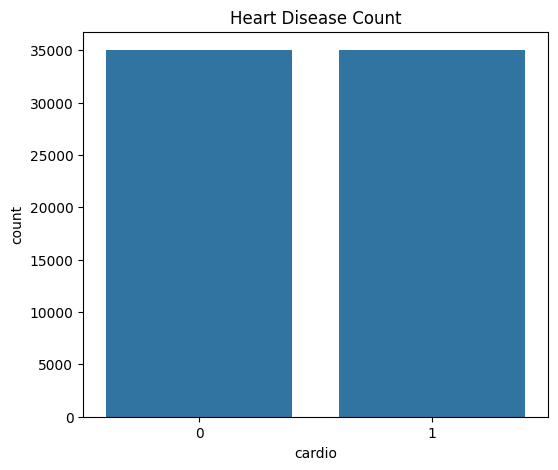

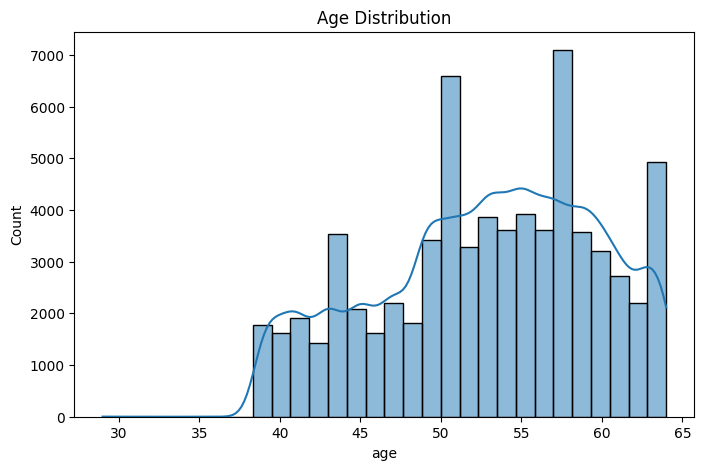

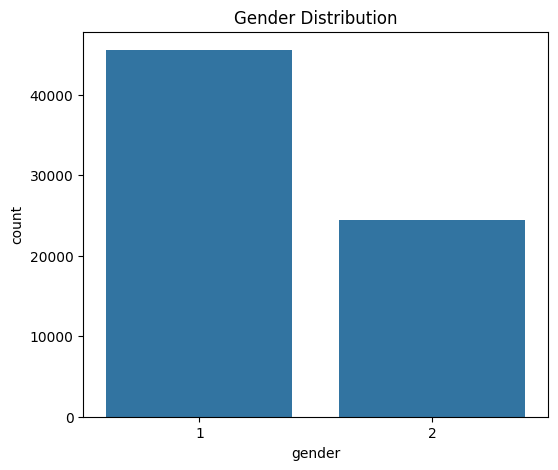

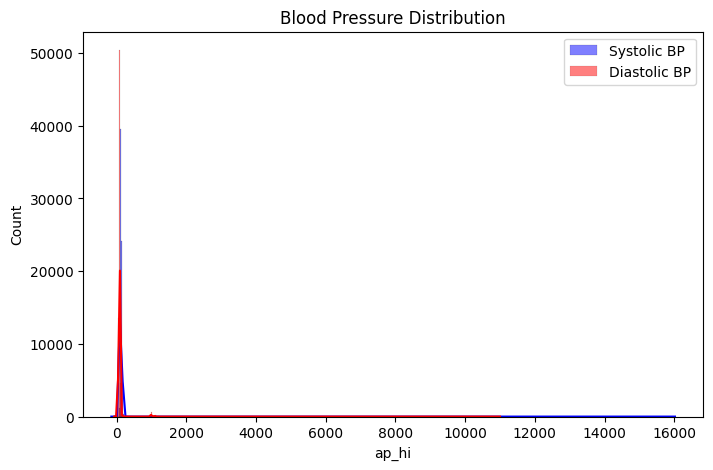

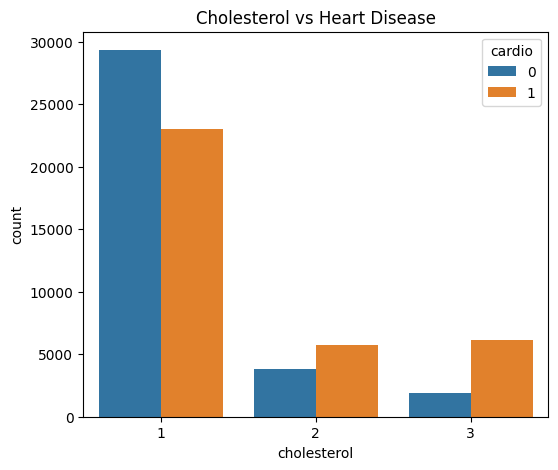

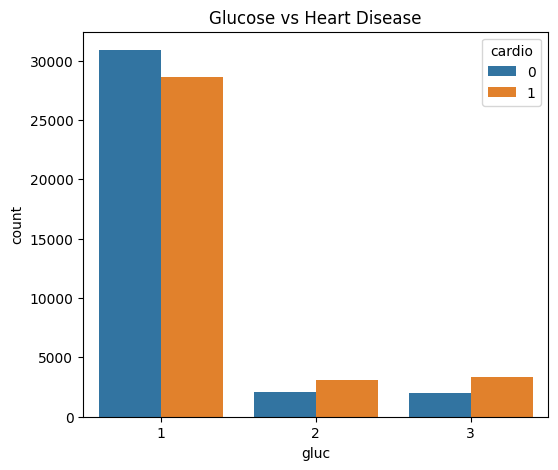

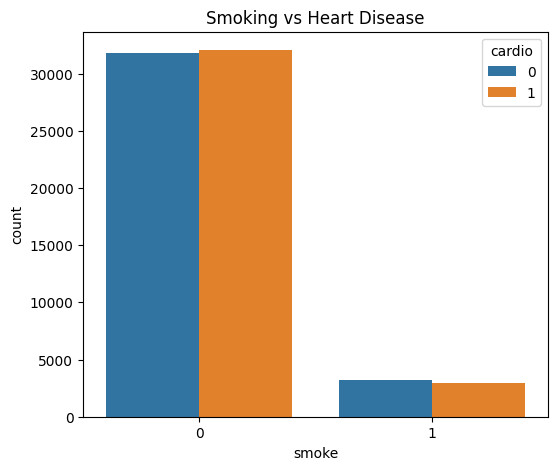

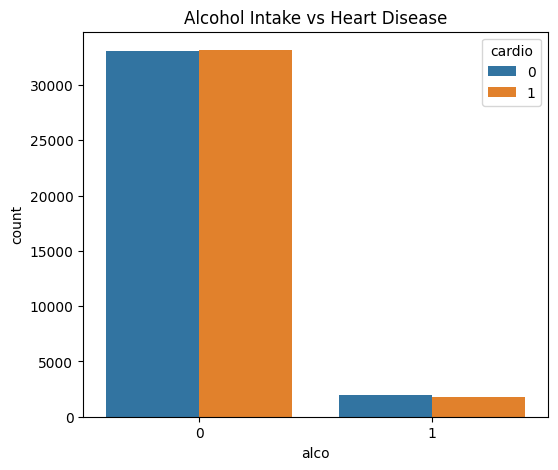

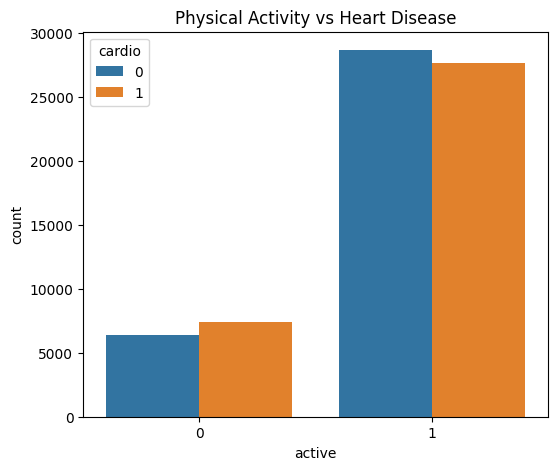

In [7]:
# ============================================
# STEP 3 : EXPLORATORY DATA ANALYSIS
# ============================================

# Target Count Plot
plt.figure(figsize=(6,5))
sns.countplot(x='cardio', data=df)
plt.title("Heart Disease Count")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Blood Pressure Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['ap_hi'], color='blue', label='Systolic BP', kde=True)
sns.histplot(df['ap_lo'], color='red', label='Diastolic BP', kde=True)
plt.legend()
plt.title("Blood Pressure Distribution")
plt.show()

# Cholesterol vs Cardio
plt.figure(figsize=(6,5))
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

# Glucose vs Cardio
plt.figure(figsize=(6,5))
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title("Glucose vs Heart Disease")
plt.show()

# Smoking vs Cardio
plt.figure(figsize=(6,5))
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title("Smoking vs Heart Disease")
plt.show()

# Alcohol Intake vs Cardio
plt.figure(figsize=(6,5))
sns.countplot(x='alco', hue='cardio', data=df)
plt.title("Alcohol Intake vs Heart Disease")
plt.show()

# Physical Activity vs Cardio
plt.figure(figsize=(6,5))
sns.countplot(x='active', hue='cardio', data=df)
plt.title("Physical Activity vs Heart Disease")
plt.show()

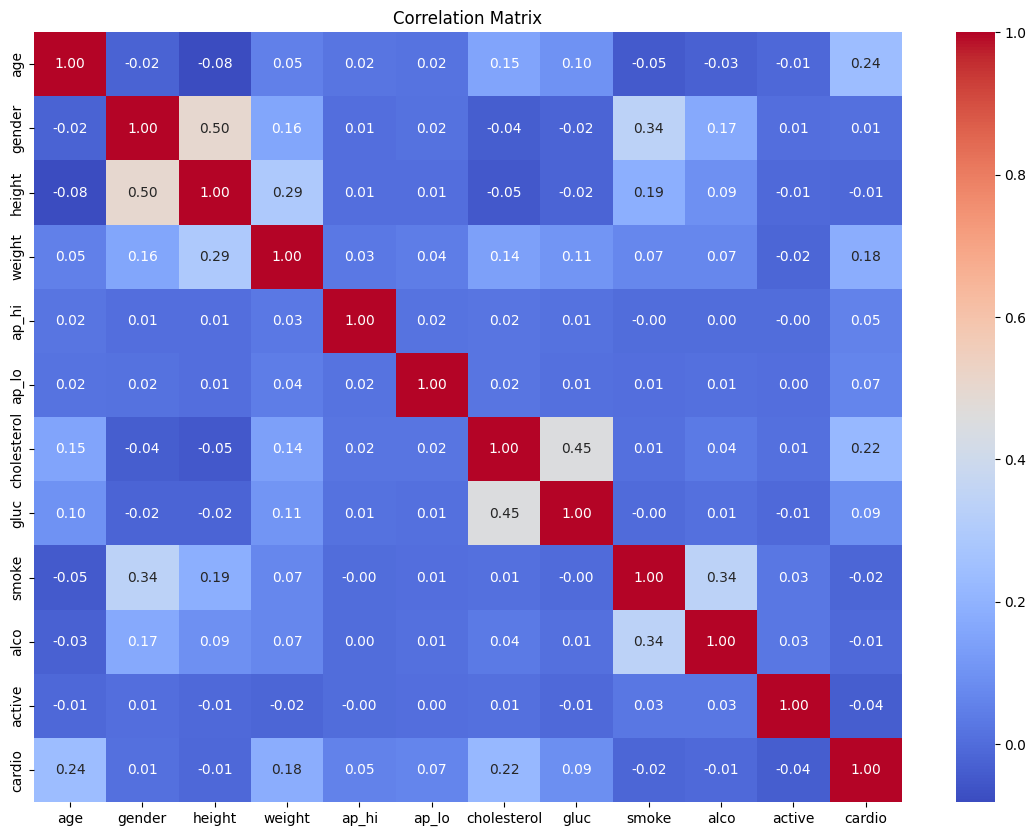

In [8]:
# ============================================
# STEP 4 : CORRELATION MATRIX
# ============================================

plt.figure(figsize=(14,10))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [9]:
# ============================================
# STEP 5 : FEATURE SELECTION
# ============================================

X = df.drop("cardio", axis=1)
y = df["cardio"]

In [10]:
# ============================================
# STEP 6 : TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
# ============================================
# STEP 7 : FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Model : Logistic Regression
Accuracy : 72.27%

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      6988
           1       0.74      0.68      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



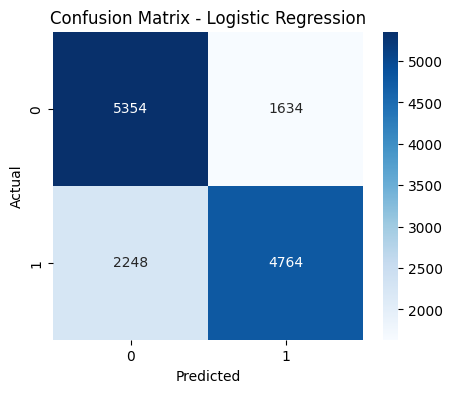


Model : KNN
Accuracy : 65.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66      6988
           1       0.66      0.63      0.65      7012

    accuracy                           0.65     14000
   macro avg       0.65      0.65      0.65     14000
weighted avg       0.65      0.65      0.65     14000



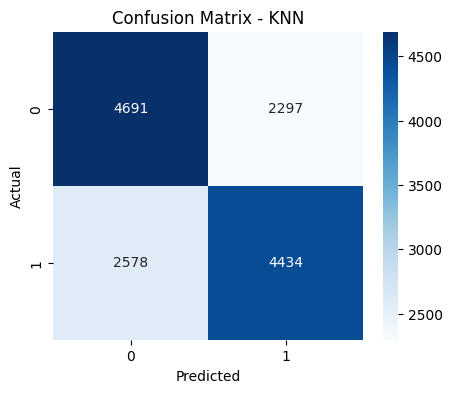


Model : Decision Tree
Accuracy : 63.51%

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      6988
           1       0.64      0.62      0.63      7012

    accuracy                           0.64     14000
   macro avg       0.64      0.64      0.63     14000
weighted avg       0.64      0.64      0.63     14000



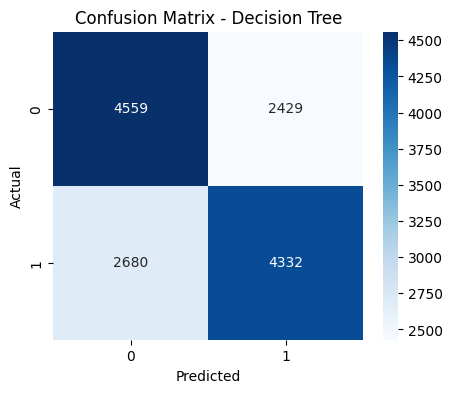


Model : Random Forest
Accuracy : 71.16%

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      6988
           1       0.71      0.71      0.71      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



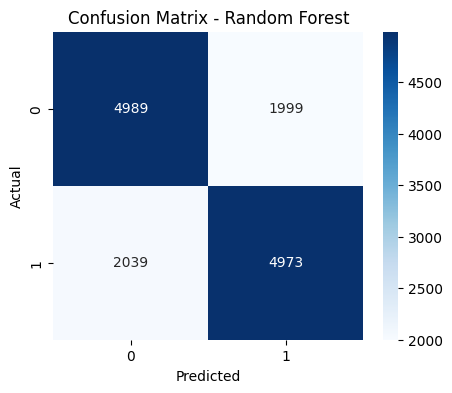


Model : SVM
Accuracy : 73.23%

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6988
           1       0.75      0.70      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



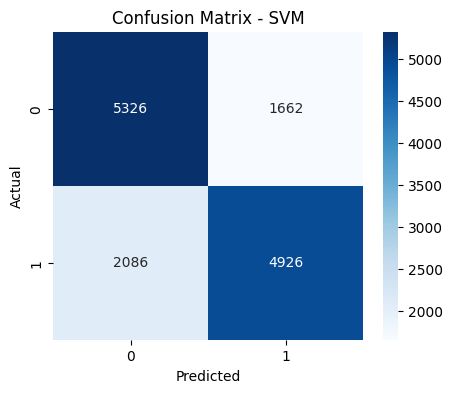

In [12]:
# ============================================
# STEP 8 : MACHINE LEARNING MODELS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

accuracies = {}

# Train and Evaluate Models
for name, model in models.items():

    print("\n===================================")
    print(f"Model : {name}")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[name] = accuracy

    print(f"Accuracy : {accuracy * 100:.2f}%")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



Model Accuracies:
                 Model  Accuracy
0  Logistic Regression  0.722714
1                  KNN  0.651786
2        Decision Tree  0.635071
3        Random Forest  0.711571
4                  SVM  0.732286


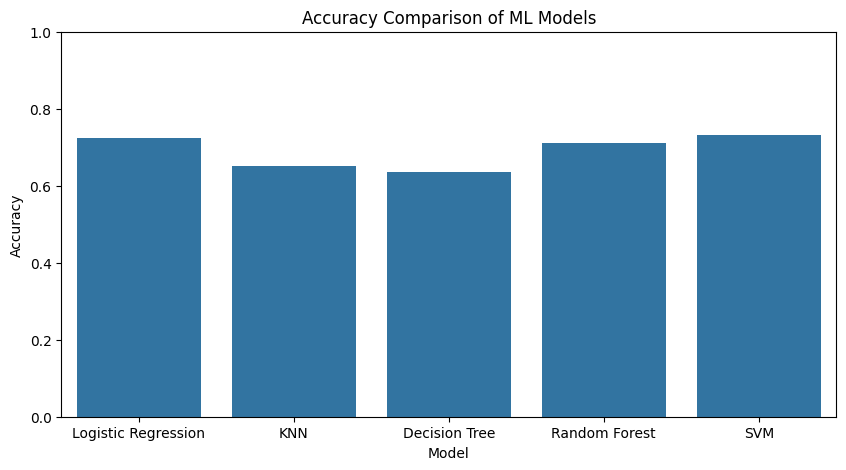

In [13]:
# ============================================
# STEP 9 : COMPARE MODEL ACCURACIES
# ============================================

accuracy_df = pd.DataFrame({
    'Model': accuracies.keys(),
    'Accuracy': accuracies.values()
})

print("\nModel Accuracies:")
print(accuracy_df)

# Accuracy Bar Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df)

plt.title("Accuracy Comparison of ML Models")
plt.ylim(0,1)
plt.show()


In [14]:
# ============================================
# STEP 10 : BEST MODEL
# ============================================

best_model = max(accuracies, key=accuracies.get)

print("\n===================================")
print(f"Best Performing Model : {best_model}")
print(f"Accuracy : {accuracies[best_model] * 100:.2f}%")
print("===================================")


Best Performing Model : SVM
Accuracy : 73.23%
